In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd


import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# XGBoost Implementation to Predict Waste Quality Scores

In [ ]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")
waste_data

,date,arrival_time,company,truck_id,waste_type,quantity_tons,quality_score,moisture_content,contamination_level,heating_value_MJ_per_kg
0,2022-01-01,2022-01-01 06:27:00,RegionalWaste Management,Reg3,Municipal,11.486050,7.929559,37.493209,2.070441,7.263229
1,2022-01-01,2022-01-01 06:32:00,RegionalWaste Management,Reg1,Industrial,19.855091,6.868888,18.746604,3.131112,11.807504
2,2022-01-01,2022-01-01 09:58:00,GreenWaste Solutions,Gre2,Organic,3.835948,6.364174,74.986417,3.635826,2.539645
3,2022-01-01,2022-01-01 10:06:00,IndustrialProcess Ltd,Ind1,Industrial,41.565434,8.821311,18.746604,1.178689,12.570800
4,2022-01-01,2022-01-01 10:14:00,GreenWaste Solutions,Gre1,Municipal,4.895075,6.149050,37.493209,3.850950,6.849568
...,...,...,...,...,...,...,...,...,...,...
17313,2024-12-31,2024-12-31 11:40:00,BuildRight Construction,Bui1,Construction,11.027408,5.704726,20.470406,4.295274,5.970507
17314,2024-12-31,2024-12-31 13:17:00,MunicipalWaste Co,Mun3,Municipal,16.620243,7.470465,34.117343,2.529535,7.385865
17315,2024-12-31,2024-12-31 13:34:00,IndustrialProcess Ltd,Ind3,Industrial,20.554325,8.548314,17.058671,1.451686,12.633587
17316,2024-12-31,2024-12-31 14:45:00,CommercialServices Inc,Com1,Commercial,16.317348,7.322251,22.744895,2.677749,9.278920


Given that we predicted the daily amount of waste for each company, one could view predicting the quality score as a regression problem.

Predicting quality score per delivery only based on the company as a feature using CatBoost:

In [3]:
X = waste_data[["company"]]
y = waste_data["quality_score"]
print(X.shape, y.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize CatBoost regressor
model = cb.CatBoostRegressor(
    iterations=550,
    depth=6,
    learning_rate= 0.08,
    loss_function='RMSE',
    verbose=False,
    allow_writing_files=False  # suppress  creation of info file

)

cat_features = [0]  

model.fit(X_train, y_train, cat_features=cat_features)

# Make predictions
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")


(17318, 1) (17318,)
RMSE: 0.7653970735538974


Will the waste type improve the prediction?

In [4]:
X = waste_data[["waste_type", "company"]]
y = waste_data["quality_score"]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features = [0,1]  

model.fit(X_train, y_train, cat_features=cat_features)


y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")


(17318, 2) (17318,)
RMSE: 0.7470963987073469


Slight improvement, though it is important to note that so far only the total amount of waste that a company delivers has been predicted. It is unknown how many deliveries of each waste type are going to happen.

In [5]:
feature_importance = model.get_feature_importance()
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df)


Feature Importance:
      Feature  Importance
1     company    76.99463
0  waste_type    23.00537


It seems like that the waste type is not that important for the prediction. Maybe because the companies specialize in a waste type so the additional information is not that helpful.
Trying out time features instead:

In [6]:
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'

In [7]:
waste_data_temp_features = waste_data.copy()

# Create time features
waste_data_temp_features['date'] = pd.to_datetime(waste_data_temp_features['date'])
waste_data_temp_features['day'] = waste_data_temp_features['date'].dt.day
waste_data_temp_features['day_of_week'] = waste_data_temp_features['date'].dt.dayofweek  # 0=Monday, 6=Sunday
waste_data_temp_features['month'] = waste_data_temp_features['date'].dt.month
waste_data_temp_features['year'] = waste_data_temp_features['date'].dt.year
waste_data_temp_features["season"] = waste_data_temp_features['date'].apply(get_season)


In [8]:
X = waste_data_temp_features[["company", "day", "day_of_week", "month", "year"]]
y = waste_data_temp_features["quality_score"]
print(X.shape, y.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Specify which features are categorical
cat_features = [0,1,2,3,4] 


model.fit(X_train, y_train, cat_features=cat_features)
y_pred = model.predict(X_test)



rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")



(17318, 5) (17318,)
RMSE: 0.6914664233279344


In [9]:
feature_importance = model.get_feature_importance()
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df)


Feature Importance:
       Feature  Importance
0      company   59.189737
3        month   23.577152
1          day    7.683167
2  day_of_week    5.226640
4         year    4.323304


In [10]:
X = waste_data_temp_features[["company", "day", "day_of_week", "month", "year","season"]]
y = waste_data_temp_features["quality_score"]
print(X.shape, y.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Specify which features are categorical
cat_features = [0,1,2,3,4,5] 


model.fit(X_train, y_train, cat_features=cat_features)
y_pred = model.predict(X_test)



rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")



(17318, 6) (17318,)
RMSE: 0.6887384660096356


In [11]:
feature_importance = model.get_feature_importance()
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df)


Feature Importance:
       Feature  Importance
0      company   52.226329
3        month   14.359099
5       season   14.339012
1          day    8.411517
2  day_of_week    6.130716
4         year    4.533328


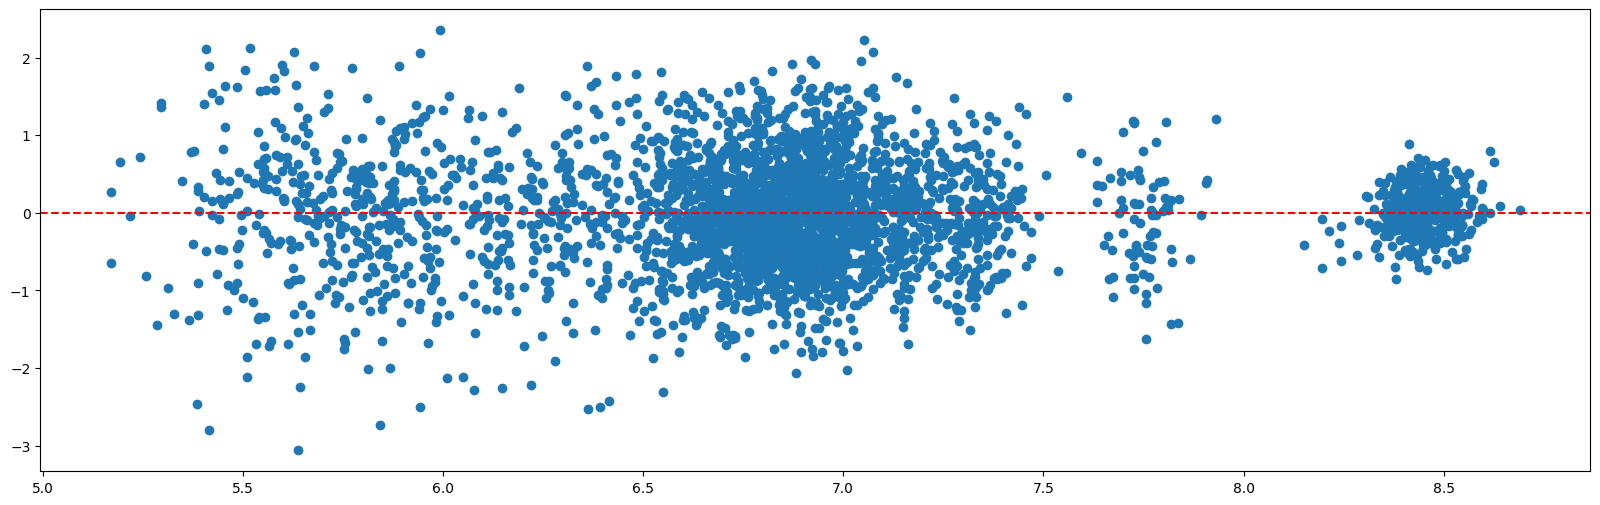

In [12]:
import matplotlib.pyplot as plt
residuals = y_pred - y_test

plt.figure(figsize= (20,6))
plt.scatter(y = residuals,x =  y_pred)
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.show()

In [13]:
i = 0
for j in residuals:
    if j > 1 or j < -1:
        i += 1

print(i)
print(i/len(y_pred))

484
0.1397228637413395


In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np

X = waste_data_temp_features[["company", "day", "day_of_week", "month", "year", "season"]]
y = waste_data_temp_features["quality_score"]

# Split the data into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Specify which features are categorical
cat_features = [0, 1, 2, 3, 4, 5]

# Define the parameter grid for grid search
param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': np.arange(0.01, 0.31, 0.05),
    'iterations': np.arange(50, 501, 50),
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': np.arange(0.5, 1.01, 0.1),
    'colsample_bylevel': np.arange(0.5, 1.01, 0.1),
    'random_strength': [0.5, 1, 1.5],
    'min_data_in_leaf': [1, 3, 5, 7, 9],
    'max_leaves': [31, 63, 127, 255],
    'bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS'],
    'score_function': ['Correlation', 'L2', 'Cosine'],
    'task_type': ['GPU']  # Use GPU if available
}

# Create the CatBoostRegressor model
model = cb.CatBoostRegressor(loss_function='RMSE', cat_features=cat_features)

# Perform grid search with cross-validation and early stopping
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,  # Number of cross-validation folds
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

grid_search.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=10)

In [ ]:
# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Make predictions using the best model on the test set
y_pred = best_model.predict(X_test)

# Calculate the RMSE on the test set
rmse = root_mean_squared_error(y_test, y_pred, squared=False)
print(f"Best parameters: {grid_search.best_params_}")
print(f"RMSE on test set: {rmse}")